In [1]:
!pip install -qq pandas numpy gymnasium stable-baselines3[extra] torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu118
!pip install -qq huggingface_hub transformers accelerate
!pip install -qq python-jsonrpc-server
!pip install stable-baselines3[extra] tensorboard -q
!pip install transformers torch -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 8.6 MB/s eta 0:00:00:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 13.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 78.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 54.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take int

In [2]:
!pip install -qq prophet pmdarima matplotlib seaborn statsmodels pandas numpy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 19.1 MB/s eta 0:00:0000:0100:01


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import os
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

In [4]:
pl.read_csv("/kaggle/input/m5-forecasting-accuracy/sales_train_evaluation.csv")

id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,…,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913,d_1914,d_1915,d_1916,d_1917,d_1918,d_1919,d_1920,d_1921,d_1922,d_1923,d_1924,d_1925,d_1926,d_1927,d_1928,d_1929,d_1930,d_1931,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
str,str,str,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""HOBBIES_1_001_CA_1_evaluation""","""HOBBIES_1_001""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,3,0,1,1,1,3,0,1,1,0,0,0,2,0,3,5,0,0,1,1,0,2,1,2,2,1,0,2,4,0,0,0,0,3,3,0,1
"""HOBBIES_1_002_CA_1_evaluation""","""HOBBIES_1_002""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,2,1,1,0,0,0,0,0
"""HOBBIES_1_003_CA_1_evaluation""","""HOBBIES_1_003""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,2,1,1,1,0,1,1,1,0,0,1,1,0,2,1,0,0,0,0,2,1,3,0,0,1,0,1,0,2,0,0,0,2,3,0,1
"""HOBBIES_1_004_CA_1_evaluation""","""HOBBIES_1_004""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,0,5,4,1,0,1,3,7,2,0,0,1,2,4,1,6,4,0,0,0,2,2,4,2,1,1,1,1,1,0,4,0,1,3,0,2,6
"""HOBBIES_1_005_CA_1_evaluation""","""HOBBIES_1_005""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,…,1,1,0,1,1,2,2,2,4,1,0,2,3,1,0,3,2,3,1,1,3,2,3,2,2,2,2,0,0,0,2,1,0,0,2,1,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""FOODS_3_823_WI_3_evaluation""","""FOODS_3_823""","""FOODS_3""","""FOODS""","""WI_3""","""WI""",0,0,2,2,0,3,1,4,1,0,0,3,4,4,0,0,1,0,1,1,7,7,3,6,3,3,7,12,4,2,7,…,0,0,0,0,0,1,0,0,1,0,0,0,2,2,0,0,0,2,0,0,1,1,1,0,0,1,0,1,0,3,0,1,1,0,0,1,1
"""FOODS_3_824_WI_3_evaluation""","""FOODS_3_824""","""FOODS_3""","""FOODS""","""WI_3""","""WI""",0,0,0,0,0,5,0,1,1,3,1,1,0,4,2,0,1,2,1,1,0,0,0,0,3,1,1,1,2,0,1,…,0,0,0,0,0,0,0,1,0,0,1,1,1,0,0,0,0,1,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
"""FOODS_3_825_WI_3_evaluation""","""FOODS_3_825""","""FOODS_3""","""FOODS""","""WI_3""","""WI""",0,6,0,2,2,4,1,8,5,2,7,5,3,5,20,8,10,3,3,4,7,2,3,5,6,3,4,1,2,5,1,…,1,0,2,0,1,0,0,1,0,0,0,1,1,0,2,1,1,0,0,1,0,0,1,0,3,3,1,0,0,1,2,0,1,0,1,0,2


In [5]:
# --- Configuration ---
DRIVE_PROJECT_PATH = '/kaggle/input/m5-forecasting-accuracy/'
OUTPUT_PATH = '/kaggle/working/'
INPUT_CSV_PATH = os.path.join(DRIVE_PROJECT_PATH, 'sales_train_evaluation.csv')
OUTPUT_TRAIN_PATH = os.path.join(OUTPUT_PATH, 'demand_train_single_product.npy')
OUTPUT_TEST_PATH = os.path.join(OUTPUT_PATH, 'demand_test_single_product.npy')
PROCESSED_DATA_EXISTS = os.path.exists(OUTPUT_TRAIN_PATH) and os.path.exists(OUTPUT_TEST_PATH)

# 3. Define Parameters
PRODUCT_ID_TO_EXTRACT = 'FOODS_3_090_CA_3_evaluation'
TRAIN_DAYS = 1500
TOTAL_DAYS = 1941 # Based on d_1 to d_1941 in sales_train_evaluation.csv

# --- Step 1: Load and Preprocess ---

if not PROCESSED_DATA_EXISTS:
    print(f"Processed data not found. Loading and processing {INPUT_CSV_PATH}...")

    # --- Action: Load specific columns using Pandas ---
    print("Generating column list...")
    # Define identifier columns
    id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id']
    # Define sales day columns (d_1 to d_1941)
    sales_cols = [f'd_{i}' for i in range(1, TOTAL_DAYS + 1)]
    # Combine columns to load
    cols_to_load = id_cols + sales_cols
    print(f"Loading {len(cols_to_load)} columns...")

    # Load the CSV with only necessary columns
    try:
        # Using Pandas as requested in the prompt description
        df = pd.read_csv(INPUT_CSV_PATH, usecols=cols_to_load)
        print(f"Loaded DataFrame shape: {df.shape}")
    except FileNotFoundError:
        print(f"ERROR: Input CSV file not found at {INPUT_CSV_PATH}")
        print("Please ensure the file exists in your Google Drive project folder and the path is correct.")
        # Exit or raise an error if the file isn't found
        raise
    except Exception as e:
        print(f"An error occurred during CSV loading: {e}")
        raise

    # --- Action: Select ONE specific product time series ---
    print(f"Filtering for product_id: {PRODUCT_ID_TO_EXTRACT}")
    product_df = df[df['id'] == PRODUCT_ID_TO_EXTRACT].copy() # Use .copy() to avoid SettingWithCopyWarning

    if product_df.empty:
        print(f"ERROR: Product ID '{PRODUCT_ID_TO_EXTRACT}' not found in the data.")
        # Optionally, list some available IDs
        print("Available IDs sample:", df['id'].head().tolist())
        raise ValueError(f"Product ID {PRODUCT_ID_TO_EXTRACT} not found.")
    else:
        print(f"Found product. Shape: {product_df.shape}")


    # --- Action: Extract the sales values into a NumPy array ---
    print("Extracting sales values...")
    # Select only the 'd_' columns and get the values as a NumPy array
    # .iloc[0] selects the first (and only) row after filtering
    # .values converts the resulting Pandas Series to a NumPy array
    demand_raw = product_df[sales_cols].iloc[0].values
    print(f"Raw demand array shape: {demand_raw.shape}")
    print(f"Raw demand data type: {demand_raw.dtype}") # Often 'object' if mixed types, or int64

    # --- Action: Handle potential missing values ---
    # M5 data might have NaNs implicitly if loaded poorly, but typically it's numeric.
    # However, sales might start later, represented by 0s. Let's ensure correct type and handle potential NaNs just in case.
    # Convert to a numeric type (float first to handle potential NaNs, then int if desired)
    # If NaNs occurred (e.g., before product launch), fill with 0
    demand_numeric = pd.to_numeric(demand_raw, errors='coerce') # Convert non-numeric to NaN
    demand_filled = np.nan_to_num(demand_numeric, nan=0.0)     # Replace NaN with 0.0
    demand_final = demand_filled.astype(np.int64)              # Convert to integer (optional)

    print(f"Processed demand array shape: {demand_final.shape}")
    print(f"Processed demand data type: {demand_final.dtype}")
    # print("Sample demand data (first 50 days):", demand_final[:50]) # Uncomment to inspect

    # --- Action: Split the demand data ---
    print(f"Splitting data into train ({TRAIN_DAYS} days) and test ({TOTAL_DAYS - TRAIN_DAYS} days)...")
    if TRAIN_DAYS >= TOTAL_DAYS:
        print("Warning: Train days is equal to or greater than total days. Test set will be empty.")
        demand_train = demand_final[:TRAIN_DAYS]
        demand_test = np.array([], dtype=demand_final.dtype) # Empty array
    else:
        demand_train = demand_final[:TRAIN_DAYS]
        demand_test = demand_final[TRAIN_DAYS:]

    print(f"Train data shape: {demand_train.shape}")
    print(f"Test data shape: {demand_test.shape}")

    # --- Action: Save the processed demand arrays ---
    print(f"Saving processed data to {DRIVE_PROJECT_PATH}...")
    # Create directory if it doesn't exist
    os.makedirs(DRIVE_PROJECT_PATH, exist_ok=True)

    np.save(OUTPUT_TRAIN_PATH, demand_train)
    np.save(OUTPUT_TEST_PATH, demand_test)
    print(f"Saved train data to: {OUTPUT_TRAIN_PATH}")
    print(f"Saved test data to: {OUTPUT_TEST_PATH}")

else:
    print("Processed data files already exist. Loading from .npy files...")
    demand_train = np.load(OUTPUT_TRAIN_PATH)
    demand_test = np.load(OUTPUT_TEST_PATH)
    print(f"Loaded train data shape: {demand_train.shape}")
    print(f"Loaded test data shape: {demand_test.shape}")

# --- Verification (Optional) ---
print("\n--- Data Ready ---")
print(f"Train data sample (first 10): {demand_train[:10]}")
print(f"Test data sample (first 10): {demand_test[:10]}")

Processed data not found. Loading and processing /kaggle/input/m5-forecasting-accuracy/sales_train_evaluation.csv...
Generating column list...
Loading 1946 columns...
Loaded DataFrame shape: (30490, 1946)
Filtering for product_id: FOODS_3_090_CA_3_evaluation
Found product. Shape: (1, 1946)
Extracting sales values...
Raw demand array shape: (1941,)
Raw demand data type: int64
Processed demand array shape: (1941,)
Processed demand data type: int64
Splitting data into train (1500 days) and test (441 days)...
Train data shape: (1500,)
Test data shape: (441,)
Saving processed data to /kaggle/input/m5-forecasting-accuracy/...
Saved train data to: /kaggle/working/demand_train_single_product.npy
Saved test data to: /kaggle/working/demand_test_single_product.npy

--- Data Ready ---
Train data sample (first 10): [108 132 102 120 106 123 279 175 186 120]
Test data sample (first 10): [  0   0   0 166 265 257 189  74  85  74]


Total Train Days: 1500
Test Horizon: 441
Validation will use train data up to day 1031
Validation target period: days 1031 to 1500

--- Loading Data ---
Loaded train data shape: (1500,)
Loaded test data shape: (441,)
Loaded calendar data shape: (1969, 14)

--- Stationarity Analysis (ADF Test) ---
ADF Test for: Original Training Data
   Test Statistic: -3.4262
   p-value: 0.0101
   Num Lags Used: 24
   Critical Values:
      1%: -3.4348
      5%: -2.8635
      10%: -2.5678
   Conclusion: Likely Stationary (Reject H0)
ADF Test for: First Difference
   Test Statistic: -9.6289
   p-value: 0.0000
   Num Lags Used: 24
   Critical Values:
      1%: -3.4348
      5%: -2.8635
      10%: -2.5678
   Conclusion: Likely Stationary (Reject H0)

Suggested differencing order (d) for ARIMA based on ADF: 0

--- ACF and PACF Plots ---


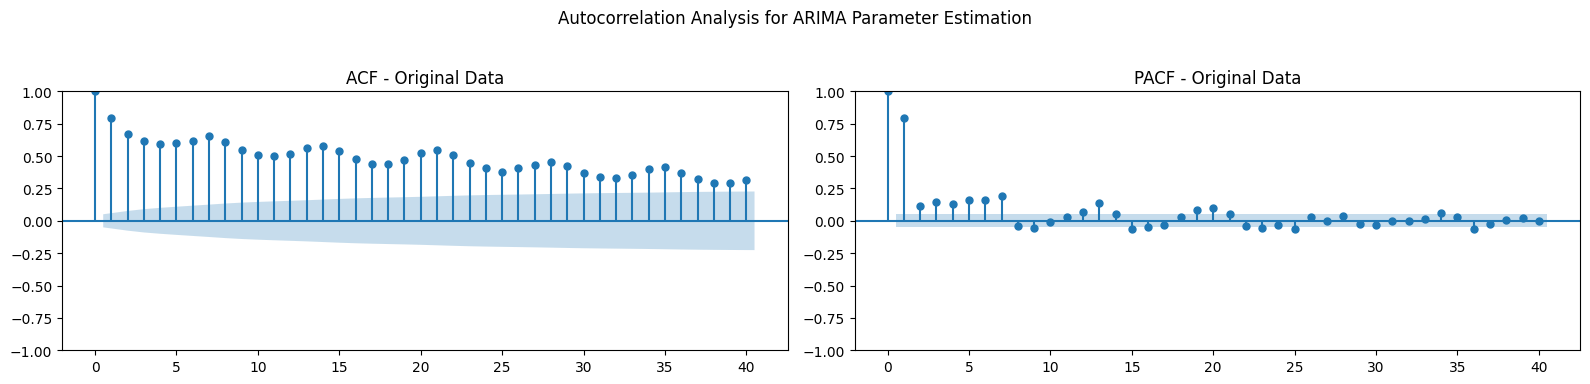

Hints for ARIMA (p, q) from plots:
 - Look at PACF for AR order (p): Cuts off after lag p.
 - Look at ACF for MA order (q): Cuts off after lag q.
   (If plots tail off gradually, suggests mixed ARMA process)

--- Preparing Validation Split (with Gap) ---
Validation Training Data: 1031 points (ends 2013-11-24)
Gap Period: 28 days
Validation Target Data: 441 points (starts 2013-12-23)

--- Prophet Model ---
Prepared 162 holiday/event instances for Prophet.
Running Prophet Validation...


23:40:53 - cmdstanpy - INFO - Chain [1] start processing
23:40:53 - cmdstanpy - INFO - Chain [1] done processing
23:40:53 - cmdstanpy - INFO - Chain [1] start processing


Prophet Validation MAE: 90.7245
Prophet Validation RMSE: 115.9884

Training Prophet on full training data...


23:40:54 - cmdstanpy - INFO - Chain [1] done processing



--- ARIMA Model ---
Running ARIMA Validation (using auto_arima)...
Auto ARIMA Validation Best Order: (5, 0, 2)
ARIMA Validation MAE: 70.7676
ARIMA Validation RMSE: 89.5336

Training ARIMA on full training data (using auto_arima)...
Auto ARIMA Final Best Order: (5, 0, 1)

--- Final Evaluation on Test Set ---
Prophet Test MAE: 78.9147
Prophet Test RMSE: 93.4564
ARIMA Test MAE: 52.9950
ARIMA Test RMSE: 68.0899

--- Plotting Forecasts vs Actuals (Test Set) ---


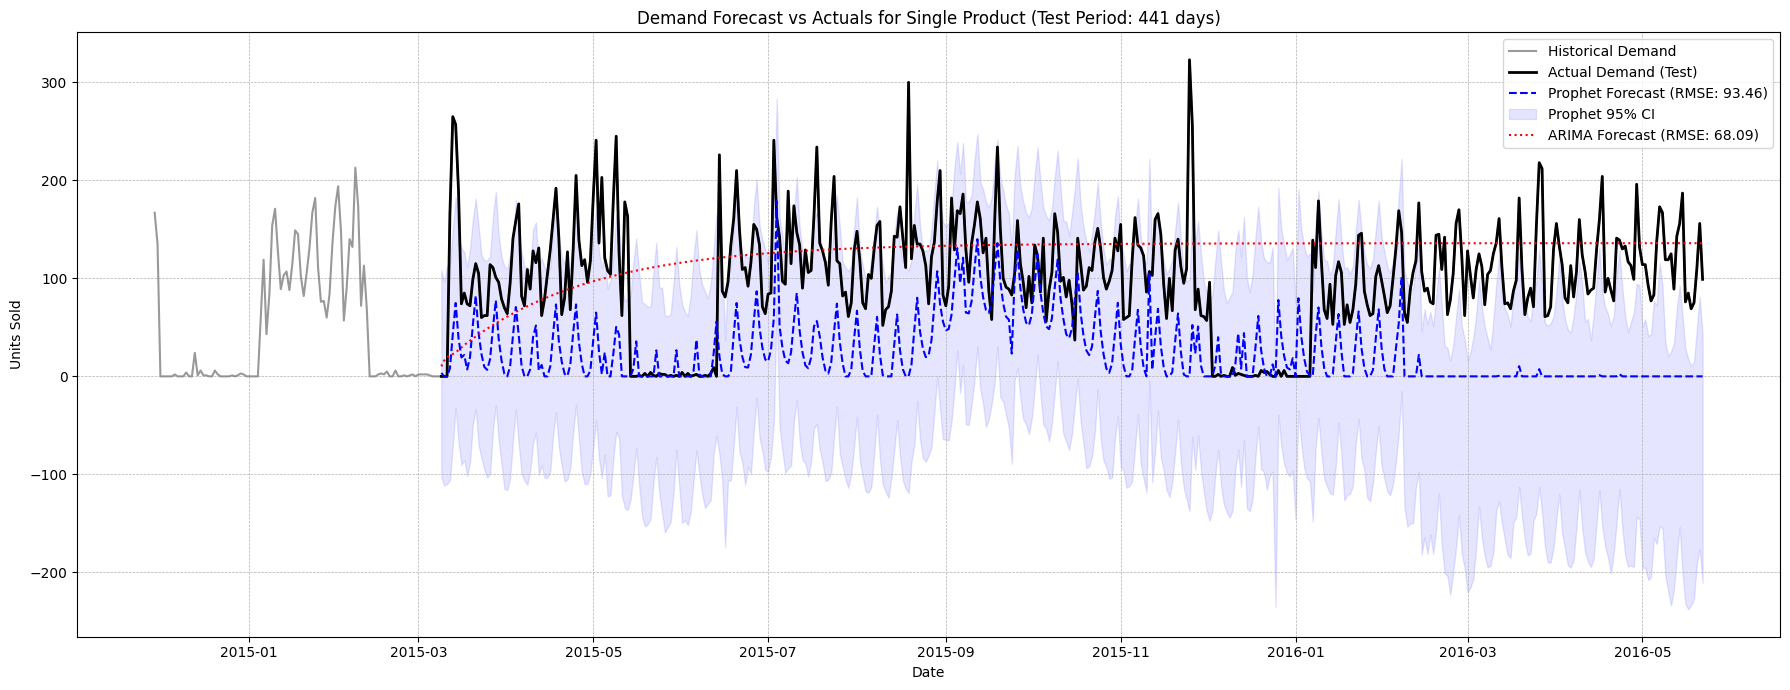

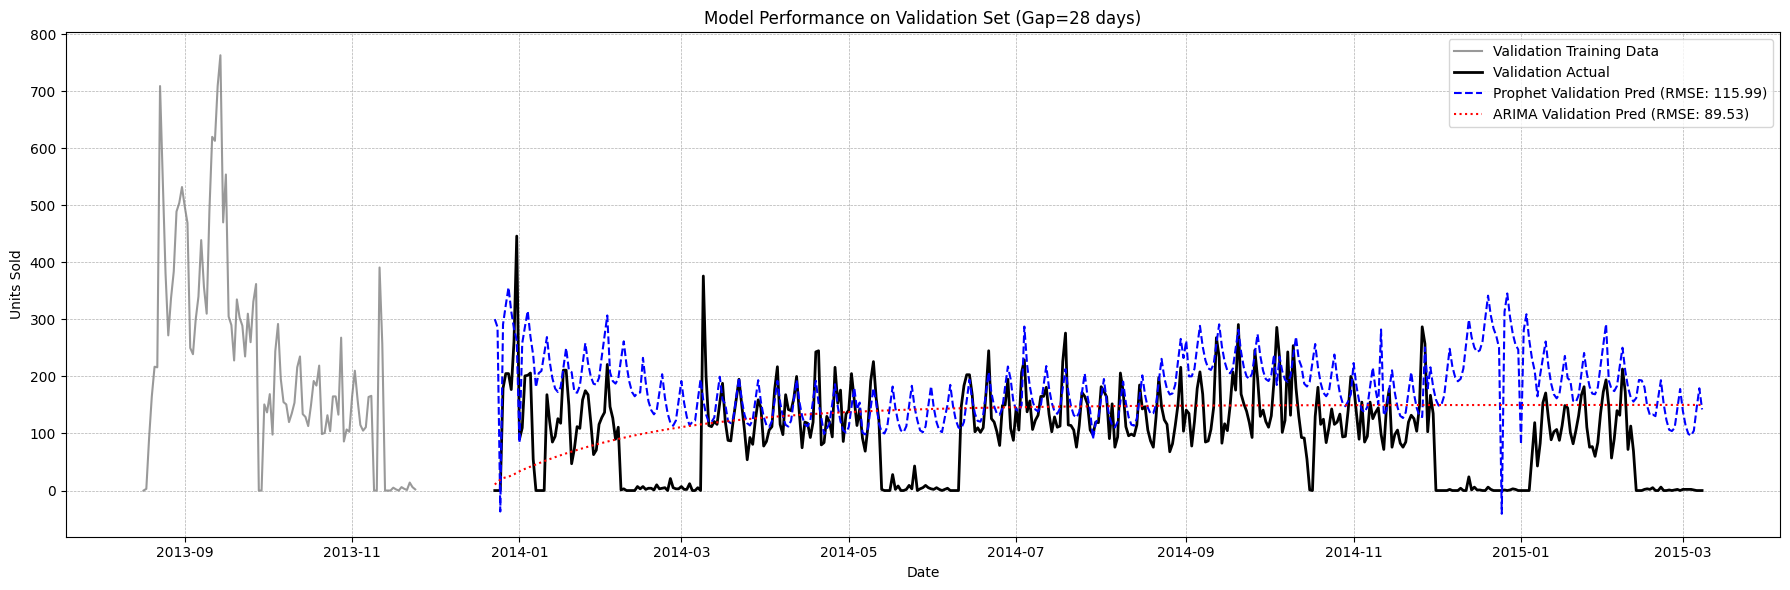

In [6]:
warnings.filterwarnings("ignore")

# --- Configuration ---

INPUT_TRAIN_PATH = os.path.join(OUTPUT_PATH, 'demand_train_single_product.npy')
INPUT_TEST_PATH = os.path.join(OUTPUT_PATH, 'demand_test_single_product.npy')
CALENDAR_CSV_PATH = os.path.join(DRIVE_PROJECT_PATH, 'calendar.csv') # Needed for dates and Prophet holidays


FORECAST_HORIZON = TOTAL_DAYS - TRAIN_DAYS # Length of the test set

# Validation Parameters
VALIDATION_SPLIT_POINT = TRAIN_DAYS - FORECAST_HORIZON - 28 # Where validation data starts (e.g., predict last 28 days of train)
# Example: Train = 1500 days, Test = 413 days.
# Let's validate on roughly a month (28 days) before the test set starts.
# Validation data will be: demand_train[1472:1500] (28 days)
# Training data for validation model: demand_train[0:1472]
# Ensure VAL_SPLIT_POINT is reasonable (not too close to beginning)
if VALIDATION_SPLIT_POINT < 50: # Need some data to train on
    print("Warning: Validation split point is very early. Adjusting.")
    VALIDATION_SPLIT_POINT = max(50, TRAIN_DAYS // 2) # Adjust if needed

print(f"Total Train Days: {TRAIN_DAYS}")
print(f"Test Horizon: {FORECAST_HORIZON}")
print(f"Validation will use train data up to day {VALIDATION_SPLIT_POINT}")
print(f"Validation target period: days {VALIDATION_SPLIT_POINT} to {TRAIN_DAYS}")


# --- Load Preprocessed Data and Calendar ---

print("\n--- Loading Data ---")
try:
    demand_train = np.load(INPUT_TRAIN_PATH)
    demand_test = np.load(INPUT_TEST_PATH)
    calendar_df = pd.read_csv(CALENDAR_CSV_PATH, parse_dates=['date'])
    print(f"Loaded train data shape: {demand_train.shape}")
    print(f"Loaded test data shape: {demand_test.shape}")
    print(f"Loaded calendar data shape: {calendar_df.shape}")
except FileNotFoundError as e:
    print(f"ERROR: Could not find data files: {e}")
    print("Please ensure demand_train*.npy, demand_test*.npy, and calendar.csv exist.")
    raise

# --- Create Date Ranges ---
# Get the dates corresponding to our train and test periods from calendar_df
if len(calendar_df) < TOTAL_DAYS:
     print(f"Warning: Calendar CSV has only {len(calendar_df)} rows, less than expected {TOTAL_DAYS_EVAL} days.")
     # Adjust if calendar is shorter than expected sales data length
     TOTAL_DAYS_ADJ = len(calendar_df)
     TRAIN_DAYS = min(TRAIN_DAYS, TOTAL_DAYS_ADJ - FORECAST_HORIZON) # Adjust train days if needed
     print(f"Adjusted Total Days: {TOTAL_DAYS_ADJ}, Adjusted Train Days: {TRAIN_DAYS}")
else:
    TOTAL_DAYS_ADJ = TOTAL_DAYS

dates = calendar_df['date'][:TOTAL_DAYS_ADJ]
train_dates = dates[:TRAIN_DAYS]
test_dates = dates[TRAIN_DAYS:TRAIN_DAYS + len(demand_test)] # Ensure correct length

if len(train_dates) != len(demand_train):
    raise ValueError(f"Mismatch: Train dates ({len(train_dates)}) vs train demand ({len(demand_train)})")
if len(test_dates) != len(demand_test):
    print(f"Warning: Test dates ({len(test_dates)}) vs test demand ({len(demand_test)}) mismatch. Truncating test demand.")
    # This might happen if calendar ends before d_1941, but sales_train_evaluation went further
    demand_test = demand_test[:len(test_dates)]
    FORECAST_HORIZON = len(demand_test) # Update horizon


# Combine into Pandas Series for easier handling
ts_train_pd = pd.Series(demand_train, index=train_dates, name='demand')
ts_test_pd = pd.Series(demand_test, index=test_dates, name='demand')
ts_full_pd = pd.concat([ts_train_pd, ts_test_pd])

# --- Stationarity Analysis ---
print("\n--- Stationarity Analysis (ADF Test) ---")

def perform_adf_test(series, series_name):
    """Performs ADF test and prints results."""
    result = adfuller(series.dropna()) # Drop NA if differencing created them
    print(f'ADF Test for: {series_name}')
    print(f'   Test Statistic: {result[0]:.4f}')
    print(f'   p-value: {result[1]:.4f}')
    print(f'   Num Lags Used: {result[2]}')
    print(f'   Critical Values:')
    for key, value in result[4].items():
        print(f'      {key}: {value:.4f}')
    if result[1] <= 0.05:
        print(f'   Conclusion: Likely Stationary (Reject H0)')
        return True
    else:
        print(f'   Conclusion: Likely Non-Stationary (Fail to reject H0)')
        return False

# Test original data
is_stationary_orig = perform_adf_test(ts_train_pd, "Original Training Data")

# Test first difference
ts_train_diff1 = ts_train_pd.diff().dropna()
is_stationary_diff1 = perform_adf_test(ts_train_diff1, "First Difference")
arima_d = 0 if is_stationary_orig else 1 # Start guessing the 'd' parameter

# Test second difference (only if first difference wasn't stationary)
if not is_stationary_orig and not is_stationary_diff1:
    ts_train_diff2 = ts_train_diff1.diff().dropna()
    is_stationary_diff2 = perform_adf_test(ts_train_diff2, "Second Difference")
    if is_stationary_diff2:
        arima_d = 2
else:
    is_stationary_diff2 = False # Not tested or not stationary

print(f"\nSuggested differencing order (d) for ARIMA based on ADF: {arima_d}")

# --- ACF/PACF Plots (on the stationary series) ---
print("\n--- ACF and PACF Plots ---")
stationary_series_for_plots = ts_train_pd
plot_title_suffix = "Original Data"
if arima_d == 1:
    stationary_series_for_plots = ts_train_diff1
    plot_title_suffix = "First Difference"
elif arima_d == 2:
    stationary_series_for_plots = ts_train_diff2
    plot_title_suffix = "Second Difference"

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(stationary_series_for_plots, ax=axes[0], lags=40, title=f'ACF - {plot_title_suffix}')
plot_pacf(stationary_series_for_plots, ax=axes[1], lags=40, title=f'PACF - {plot_title_suffix}', method='ywm') # 'ywm' is often preferred
plt.suptitle("Autocorrelation Analysis for ARIMA Parameter Estimation")
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

print("Hints for ARIMA (p, q) from plots:")
print(" - Look at PACF for AR order (p): Cuts off after lag p.")
print(" - Look at ACF for MA order (q): Cuts off after lag q.")
print("   (If plots tail off gradually, suggests mixed ARMA process)")

# --- Validation Split with Gap ---
print("\n--- Preparing Validation Split (with Gap) ---")

# Define the gap period
# The validation training data ends at VALIDATION_SPLIT_POINT
# The validation target data starts after the gap
# Let's use a 28-day gap as initially planned
GAP_DAYS = 28
validation_train_end_index = VALIDATION_SPLIT_POINT
validation_target_start_index = validation_train_end_index + GAP_DAYS

if validation_target_start_index >= TRAIN_DAYS:
    print("Warning: Gap is too large, validation target period is empty or invalid. Reducing gap.")
    # Reduce gap to have at least some validation days (e.g., 14 days)
    MIN_VAL_DAYS = 14
    GAP_DAYS = max(0, TRAIN_DAYS - validation_train_end_index - MIN_VAL_DAYS)
    validation_target_start_index = validation_train_end_index + GAP_DAYS
    print(f"Adjusted Gap: {GAP_DAYS} days")

# Extract validation training and target sets
train_val = ts_train_pd[:validation_train_end_index]
# The actual values we want to predict in validation
validation_target = ts_train_pd[validation_target_start_index:]
validation_target_dates = ts_train_pd.index[validation_target_start_index:]
validation_horizon = len(validation_target)

print(f"Validation Training Data: {len(train_val)} points (ends {train_val.index.max().date()})")
print(f"Gap Period: {GAP_DAYS} days")
print(f"Validation Target Data: {len(validation_target)} points (starts {validation_target.index.min().date()})")


# --- Prophet Model ---
print("\n--- Prophet Model ---")

# Prepare holidays for Prophet
holidays = calendar_df[calendar_df['event_name_1'].notna() | calendar_df['event_name_2'].notna()][['date', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']].copy()
holidays['event_name_1'] = holidays['event_name_1'].fillna('')
holidays['event_name_2'] = holidays['event_name_2'].fillna('')
holidays['holiday'] = holidays['event_name_1'] + holidays['event_name_2'] # Combine potential events
holidays = holidays[holidays['holiday'] != ''][['date', 'holiday']].rename(columns={'date': 'ds'})
holidays['lower_window'] = 0 # Point events
holidays['upper_window'] = 0
print(f"Prepared {len(holidays)} holiday/event instances for Prophet.")

# 1. Prophet Validation
print("Running Prophet Validation...")
prophet_train_df_val = pd.DataFrame({'ds': train_val.index, 'y': train_val.values})

m_prophet_val = Prophet(holidays=holidays, weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False) # Daily is often too noisy for sales
m_prophet_val.fit(prophet_train_df_val)

future_val = pd.DataFrame({'ds': validation_target_dates})
forecast_val_prophet = m_prophet_val.predict(future_val)

# Extract predictions for the validation period
prophet_preds_val = forecast_val_prophet['yhat'].values

# Evaluate Prophet on Validation Set
mae_prophet_val = mean_absolute_error(validation_target.values, prophet_preds_val)
rmse_prophet_val = np.sqrt(mean_squared_error(validation_target.values, prophet_preds_val))
print(f"Prophet Validation MAE: {mae_prophet_val:.4f}")
print(f"Prophet Validation RMSE: {rmse_prophet_val:.4f}")


# 2. Prophet Final Fit and Forecast on Test Set
print("\nTraining Prophet on full training data...")
prophet_train_df_full = pd.DataFrame({'ds': ts_train_pd.index, 'y': ts_train_pd.values})

m_prophet_final = Prophet(holidays=holidays, weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
m_prophet_final.fit(prophet_train_df_full)

# Create future dataframe for the test period
future_test = pd.DataFrame({'ds': test_dates})
forecast_test_prophet = m_prophet_final.predict(future_test)

# Extract predictions for the test period
prophet_preds_test = forecast_test_prophet['yhat'].values

# --- ARIMA Model ---
print("\n--- ARIMA Model ---")
# Using pmdarima.auto_arima for automatic order selection

# 1. ARIMA Validation
print("Running ARIMA Validation (using auto_arima)...")
# Use the 'd' found earlier, let auto_arima find p, q
try:
    auto_model_val = auto_arima(train_val.values,
                                start_p=1, start_q=1,
                                max_p=5, max_q=5, # Limit search space
                                d=arima_d,        # Use d from ADF test
                                seasonal=False,   # Start without seasonality for simplicity, can add later (m=7 for weekly)
                                stepwise=True,    # Faster search
                                suppress_warnings=True,
                                error_action='ignore') # Skip models that fail

    print(f"Auto ARIMA Validation Best Order: {auto_model_val.order}")
    arima_preds_val = auto_model_val.predict(n_periods=validation_horizon)

    # Evaluate ARIMA on Validation Set
    mae_arima_val = mean_absolute_error(validation_target.values, arima_preds_val)
    rmse_arima_val = np.sqrt(mean_squared_error(validation_target.values, arima_preds_val))
    print(f"ARIMA Validation MAE: {mae_arima_val:.4f}")
    print(f"ARIMA Validation RMSE: {rmse_arima_val:.4f}")

except Exception as e:
    print(f"Auto ARIMA validation failed: {e}")
    auto_model_val = None
    arima_preds_val = np.zeros(validation_horizon) # Placeholder


# 2. ARIMA Final Fit and Forecast on Test Set
print("\nTraining ARIMA on full training data (using auto_arima)...")
try:
    # Re-run auto_arima on the full training data
    auto_model_final = auto_arima(ts_train_pd.values,
                                  start_p=1, start_q=1,
                                  max_p=5, max_q=5,
                                  d=arima_d, # Use d from ADF test
                                  seasonal=False, # Keep consistent, consider adding seasonal=True, m=7
                                  stepwise=True,
                                  suppress_warnings=True,
                                  error_action='ignore')

    print(f"Auto ARIMA Final Best Order: {auto_model_final.order}")
    arima_preds_test = auto_model_final.predict(n_periods=FORECAST_HORIZON)

    # Optional: If auto_arima failed on validation, use the validation order if it succeeded
    if auto_model_val is not None and auto_model_final is None:
         print("Final auto_arima failed, attempting with validation order...")
         from statsmodels.tsa.arima.model import ARIMA
         manual_arima = ARIMA(ts_train_pd.values, order=auto_model_val.order)
         manual_arima_fit = manual_arima.fit()
         arima_preds_test = manual_arima_fit.predict(start=len(ts_train_pd), end=len(ts_train_pd) + FORECAST_HORIZON - 1)


except Exception as e:
    print(f"Auto ARIMA final fit/prediction failed: {e}")
    # Fallback: Use a simple ARIMA model or zeros if auto_arima fails completely
    try:
        print("Falling back to simple ARIMA(1,d,0)...")
        from statsmodels.tsa.arima.model import ARIMA
        fallback_order = (1, arima_d, 0)
        fallback_model = ARIMA(ts_train_pd.values, order=fallback_order)
        fallback_fit = fallback_model.fit()
        arima_preds_test = fallback_fit.predict(start=len(ts_train_pd), end=len(ts_train_pd) + FORECAST_HORIZON - 1)
        print(f"Using Fallback ARIMA{fallback_order}")
    except Exception as e_fb:
        print(f"Fallback ARIMA also failed: {e_fb}. Using zeros for prediction.")
        arima_preds_test = np.zeros(FORECAST_HORIZON) # Placeholder if everything fails


# Ensure predictions are non-negative (sales cannot be negative)
prophet_preds_test[prophet_preds_test < 0] = 0
arima_preds_test[arima_preds_test < 0] = 0

# --- Evaluation on Test Set ---
print("\n--- Final Evaluation on Test Set ---")

mae_prophet_test = mean_absolute_error(ts_test_pd.values, prophet_preds_test)
rmse_prophet_test = np.sqrt(mean_squared_error(ts_test_pd.values, prophet_preds_test))

mae_arima_test = mean_absolute_error(ts_test_pd.values, arima_preds_test)
rmse_arima_test = np.sqrt(mean_squared_error(ts_test_pd.values, arima_preds_test))

print(f"Prophet Test MAE: {mae_prophet_test:.4f}")
print(f"Prophet Test RMSE: {rmse_prophet_test:.4f}")
print(f"ARIMA Test MAE: {mae_arima_test:.4f}")
print(f"ARIMA Test RMSE: {rmse_arima_test:.4f}")

# --- Visualization ---
print("\n--- Plotting Forecasts vs Actuals (Test Set) ---")

plt.figure(figsize=(18, 7))

# Plot historical data (last part of training for context + test data)
history_plot_days = 100 # How many days of history to show before the forecast starts
plt.plot(ts_full_pd.index[TRAIN_DAYS-history_plot_days:], ts_full_pd.values[TRAIN_DAYS-history_plot_days:], label='Historical Demand', color='gray', alpha=0.8)

# Plot actual test data
plt.plot(ts_test_pd.index, ts_test_pd.values, label='Actual Demand (Test)', color='black', linewidth=2)

# Plot Prophet forecast
plt.plot(test_dates, prophet_preds_test, label=f'Prophet Forecast (RMSE: {rmse_prophet_test:.2f})', color='blue', linestyle='--')
# Access confidence intervals from prophet forecast dataframe
plt.fill_between(test_dates, forecast_test_prophet['yhat_lower'].values, forecast_test_prophet['yhat_upper'].values, color='blue', alpha=0.1, label='Prophet 95% CI')


# Plot ARIMA forecast
plt.plot(test_dates, arima_preds_test, label=f'ARIMA Forecast (RMSE: {rmse_arima_test:.2f})', color='red', linestyle=':')
# Note: Getting confidence intervals for ARIMA requires more steps, especially with auto_arima. Skipping here for brevity.


plt.title(f'Demand Forecast vs Actuals for Single Product (Test Period: {FORECAST_HORIZON} days)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Optional: Plot validation period forecast
plt.figure(figsize=(18, 6))
plt.plot(train_val.index[-history_plot_days:], train_val.values[-history_plot_days:], label='Validation Training Data', color='gray', alpha=0.8)
plt.plot(validation_target.index, validation_target.values, label='Validation Actual', color='black', linewidth=2)
plt.plot(validation_target.index, prophet_preds_val, label=f'Prophet Validation Pred (RMSE: {rmse_prophet_val:.2f})', color='blue', linestyle='--')
if 'arima_preds_val' in locals() and arima_preds_val is not None : # Check if ARIMA validation ran
    plt.plot(validation_target.index, arima_preds_val, label=f'ARIMA Validation Pred (RMSE: {rmse_arima_val:.2f})', color='red', linestyle=':')
plt.title(f'Model Performance on Validation Set (Gap={GAP_DAYS} days)')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

In [10]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces
import warnings

class InventoryEnv(gym.Env):
    """
    A custom Gymnasium environment for simulating a single-product inventory system.

    Observation Space:
        Box(low=0, high=max_inventory, shape=(1,), dtype=np.float32)
        Represents the current on-hand inventory level.

    Action Space:
        Discrete(n)
        Where n corresponds to the number of possible order quantities
        (e.g., 0, 10, 20, ..., max_order_quantity).

    Reward:
        Default: Negative total cost (holding + stockout + order).
        Can be configured to include revenue.

    Episode Termination:
        The episode ends when the demand data runs out.
    """
    metadata = {"render_modes": [], "render_fps": 1} # No rendering implemented

    def __init__(self,
                 demand_data: np.ndarray,
                 lead_time: int = 1,
                 holding_cost: float = 0.1,
                 stockout_cost: float = 1.0,
                 order_cost: float = 0.0, # Optional fixed cost per order placed
                 unit_price: float = 2.0, # Optional revenue per unit sold
                 max_inventory: int = 1000,
                 max_order_quantity: int = 100,
                 order_step_size: int = 10, # Orders must be multiples of this
                 initial_inventory: int = 0,
                 include_revenue_in_reward: bool = False # If True, reward = profit, else reward = -cost
                ):
        """
        Initializes the inventory environment.

        Args:
            demand_data: NumPy array of daily demand values.
            lead_time: Number of days for an order to arrive. Min 0 (arrives start of next day).
            holding_cost: Cost per unit held in inventory per day (charged on ending inventory).
            stockout_cost: Cost per unit of unmet demand per day.
            order_cost: Fixed cost incurred whenever an order > 0 is placed.
            unit_price: Revenue per unit sold.
            max_inventory: Maximum allowable inventory level (capacity).
            max_order_quantity: The largest single order quantity allowed.
            order_step_size: Order quantities must be multiples of this step size.
            initial_inventory: Inventory level at the start of an episode.
            include_revenue_in_reward: Whether to maximize profit or minimize cost.
        """
        super().__init__()

        if not isinstance(demand_data, np.ndarray) or demand_data.ndim != 1:
            raise ValueError("demand_data must be a 1D NumPy array.")
        if lead_time < 0:
            raise ValueError("lead_time cannot be negative.")
        if max_inventory <= 0:
             raise ValueError("max_inventory must be positive.")
        if max_order_quantity < 0 or order_step_size <= 0 or max_order_quantity % order_step_size != 0:
            raise ValueError("Invalid order quantity parameters.")

        self.demand_data = demand_data.astype(np.int32) # Ensure integer demand
        self.episode_length = len(demand_data)
        self.lead_time = lead_time
        self.holding_cost = holding_cost
        self.stockout_cost = stockout_cost
        self.order_cost = order_cost
        self.unit_price = unit_price
        self.max_inventory = max_inventory
        self.max_order_quantity = max_order_quantity
        self.order_step_size = order_step_size
        self.initial_inventory = min(initial_inventory, max_inventory) # Cap initial inventory
        self.include_revenue_in_reward = include_revenue_in_reward

        # --- Define Action Space ---
        # Possible order quantities: 0, step, 2*step, ..., max_order_quantity
        self.possible_orders = np.arange(0, self.max_order_quantity + self.order_step_size, self.order_step_size, dtype=np.int32)
        self.action_space = spaces.Discrete(len(self.possible_orders))
        self._action_to_quantity = {i: q for i, q in enumerate(self.possible_orders)}
        print(f"Action space: {self.action_space}")
        print(f"Action -> Quantity mapping: {self._action_to_quantity}")


        # --- Define Observation Space ---
        # Simple: Just current on-hand inventory
        self.observation_space = spaces.Box(
            low=0, high=self.max_inventory, shape=(1,), dtype=np.float32
        )
        print(f"Observation space: {self.observation_space}")

        # --- Initialize State Variables (will be reset) ---
        self.current_day_index = 0
        self.current_inventory = 0 # Will be set in reset()
        # Dictionary to track orders: {arrival_day: quantity}
        self.on_order_inventory = {}

        # --- Check for potential issues ---
        if self.episode_length == 0:
            warnings.warn("Demand data is empty. Environment cannot run.")


    def _get_obs(self) -> np.ndarray:
        """Returns the current observation."""
        return np.array([self.current_inventory], dtype=np.float32)

    def _get_info(self) -> dict:
        """Returns auxiliary information about the current step."""
        # You can customize this dict to include helpful info for debugging or analysis
        return {
            "day": self.current_day_index,
            "inventory_level": self.current_inventory,
            "on_order": sum(self.on_order_inventory.values()),
            # Add info from the *previous* step if needed (demand, sales etc.)
            # This might require storing them temporarily in self during step()
        }

    def reset(self, seed=None, options=None) -> tuple[np.ndarray, dict]:
        """
        Resets the environment to the initial state for a new episode.

        Args:
            seed: Optional random seed for reproducibility.
            options: Optional dictionary with environment-specific options.

        Returns:
            A tuple containing the initial observation and an info dictionary.
        """
        super().reset(seed=seed) # Important for seeding internal RNG if needed

        self.current_day_index = 0
        self.current_inventory = self.initial_inventory
        self.on_order_inventory = {}

        observation = self._get_obs()
        info = self._get_info()

        # print(f"Environment Reset: Day={self.current_day_index}, Inv={self.current_inventory}") # Debug print
        return observation, info

    def step(self, action: int) -> tuple[np.ndarray, float, bool, bool, dict]:
        """
        Executes one time step within the environment.

        Args:
            action: An integer representing the chosen action (index in possible_orders).

        Returns:
            A tuple containing:
                observation (np.ndarray): The observation after the step.
                reward (float): The reward obtained during the step.
                terminated (bool): Whether the episode has ended naturally (end of data).
                truncated (bool): Whether the episode was ended prematurely (not used here).
                info (dict): Auxiliary information.
        """
        if self.current_day_index >= self.episode_length:
             warnings.warn("Step called after environment termination.", UserWarning)
             # Still return valid types, potentially with zero reward and terminal state
             obs = self._get_obs()
             info = self._get_info()
             return obs, 0.0, True, False, info

        # --- 1. Get Actual Order Quantity from Action ---
        actual_order_quantity = self._action_to_quantity[action]
        order_placed_cost = self.order_cost if actual_order_quantity > 0 else 0.0

        # --- 2. Check for Arriving Orders ---
        arriving_orders = self.on_order_inventory.pop(self.current_day_index, 0) # Get and remove orders arriving today
        # print(f"Day {self.current_day_index}: Arriving={arriving_orders}") # Debug print

        # --- 3. Update Inventory with Arrivals (Cap at Max) ---
        self.current_inventory += arriving_orders
        # Calculate overflow (optional - could be penalized)
        overflow = max(0, self.current_inventory - self.max_inventory)
        self.current_inventory = min(self.current_inventory, self.max_inventory)
        # print(f"Day {self.current_day_index}: Inv after arrival={self.current_inventory}") # Debug print


        # --- 4. Get Demand for the Current Day ---
        demand = self.demand_data[self.current_day_index]
        # print(f"Day {self.current_day_index}: Demand={demand}") # Debug print


        # --- 5. Calculate Sales and Unmet Demand ---
        sales = min(demand, self.current_inventory)
        unmet_demand = demand - sales
        # print(f"Day {self.current_day_index}: Sales={sales}, Unmet={unmet_demand}") # Debug print


        # --- 6. Update Inventory After Sales ---
        self.current_inventory -= sales
        # print(f"Day {self.current_day_index}: Inv after sales={self.current_inventory}") # Debug print


        # --- 7. Calculate Costs for the Day ---
        holding_cost_today = self.current_inventory * self.holding_cost
        stockout_cost_today = unmet_demand * self.stockout_cost

        # --- 8. Calculate Reward ---
        if self.include_revenue_in_reward:
            revenue_today = sales * self.unit_price
            reward = revenue_today - holding_cost_today - stockout_cost_today - order_placed_cost
        else:
            # Minimize cost (negative reward)
            reward = - (holding_cost_today + stockout_cost_today + order_placed_cost)
            # Optional: Add penalty for overflow? e.g., - overflow * some_penalty

        # print(f"Day {self.current_day_index}: Costs(H={holding_cost_today:.2f}, S={stockout_cost_today:.2f}, O={order_placed_cost:.2f}), Reward={reward:.2f}") # Debug print


        # --- 9. Place the New Order (if any) ---
        if actual_order_quantity > 0:
            arrival_day = self.current_day_index + self.lead_time
            self.on_order_inventory[arrival_day] = self.on_order_inventory.get(arrival_day, 0) + actual_order_quantity
            # print(f"Day {self.current_day_index}: Placed order={actual_order_quantity}, arrives day {arrival_day}") # Debug print


        # --- 10. Advance Time ---
        self.current_day_index += 1

        # --- 11. Check for Termination ---
        terminated = self.current_day_index >= self.episode_length
        truncated = False # Not using truncation based on step limits here

        # --- 12. Get Next State Observation and Info ---
        observation = self._get_obs()
        info = { # Update info with step results
            "day": self.current_day_index -1, # Reflects the day that just finished
            "demand": demand,
            "sales": sales,
            "unmet_demand": unmet_demand,
            "holding_cost": holding_cost_today,
            "stockout_cost": stockout_cost_today,
            "order_cost": order_placed_cost,
            "order_placed": actual_order_quantity,
            "inventory_start_day": self.current_inventory + sales - arriving_orders, # Inv before arrivals
            "inventory_after_arrival": self.current_inventory + sales, # Inv after arrivals, before demand
            "inventory_end_day": self.current_inventory,
            "arriving_orders": arriving_orders,
            "on_order_total": sum(self.on_order_inventory.values()),
            "reward": reward,
            "overflow": overflow
        }

        return observation, reward, terminated, truncated, info

    def close(self):
        """Perform any necessary cleanup."""
        # print("Closing InventoryEnv.")
        pass # Nothing specific needed for this simple environment

# --- Example Usage & Testing ---

if __name__ == "__main__":
    print("--- Testing Inventory Environment ---")

    # Sample demand data
    # demand = np.random.randint(5, 25, size=50) # Random demand for 50 days
    demand = np.array([10, 12, 8, 15, 20, 5, 9, 11, 18, 22] * 5) # More structured demand

    # Environment parameters
    params = {
        "demand_data": demand,
        "lead_time": 2,         # Orders take 2 days to arrive
        "holding_cost": 0.2,    # Cost 0.2 per unit held per day
        "stockout_cost": 2.0,   # Cost 2.0 per unit of unmet demand
        "order_cost": 5.0,      # Fixed cost of 5.0 if any order is placed
        "max_inventory": 80,
        "max_order_quantity": 50,
        "order_step_size": 10,  # Order 0, 10, 20, 30, 40, or 50 units
        "initial_inventory": 20,
        "include_revenue_in_reward": False # Minimize costs
    }

    env = InventoryEnv(**params)

    # --- Test Environment Conformance ---
    try:
        from gymnasium.utils.env_checker import check_env
        print("\n--- Running Gymnasium Env Checker ---")
        check_env(env)
        print("Environment check passed!")
    except ImportError:
        print("Install gymnasium[mujoco] or run `pip install gymnasium[classic_control]` to run the env checker.")
    except Exception as e:
        print(f"Environment check failed: {e}")


    # --- Manual Simulation Test ---
    print("\n--- Running Manual Simulation Test (15 steps) ---")
    obs, info = env.reset()
    total_reward = 0
    terminated = False
    truncated = False
    step_count = 0

    # Simple policy: If inventory < 30, order 30 (action index 3 if step=10, max>=30)
    # Find the action index for ordering 30 units
    try:
        order_30_action = list(env._action_to_quantity.keys())[list(env._action_to_quantity.values()).index(30)]
    except ValueError:
        print("Warning: Cannot order exactly 30 units with current settings. Adjusting policy.")
        # Order the closest possible amount below or equal 30
        possible_orders = np.array(list(env._action_to_quantity.values()))
        closest_order = possible_orders[possible_orders <= 30].max()
        order_30_action = list(env._action_to_quantity.keys())[list(env._action_to_quantity.values()).index(closest_order)]
        print(f"Ordering {closest_order} units instead.")

    order_0_action = 0 # Index for ordering 0 units is always 0

    while not terminated and not truncated and step_count < 15:
        current_inv = obs[0]
        if current_inv < 30:
            action = order_30_action
            action_desc = f"Order {env._action_to_quantity[action]}"
        else:
            action = order_0_action
            action_desc = "Order 0"

        print(f"\nStep {step_count + 1}:")
        print(f"  State (Inv): {current_inv:.1f}")
        print(f"  Action Taken: {action_desc} (Index: {action})")

        obs, reward, terminated, truncated, info = env.step(action)

        print(f"  ----> Demand: {info['demand']}, Sales: {info['sales']}, Unmet: {info['unmet_demand']}")
        print(f"        Arriving: {info['arriving_orders']}, Order Cost: {info['order_cost']:.2f}")
        print(f"        Inv Start: {info['inventory_start_day']:.1f}, Inv After Arrival: {info['inventory_after_arrival']:.1f}, Inv End: {info['inventory_end_day']:.1f}")
        print(f"        Holding Cost: {info['holding_cost']:.2f}, Stockout Cost: {info['stockout_cost']:.2f}")
        print(f"        Reward: {reward:.2f}")
        print(f"        Next State (Inv): {obs[0]:.1f}")
        print(f"        Terminated: {terminated}, Truncated: {truncated}")
        print(f"        On Order Total: {info['on_order_total']}")

        total_reward += reward
        step_count += 1

    print(f"\nSimulation finished after {step_count} steps.")
    print(f"Total Reward: {total_reward:.2f}")

    env.close()

--- Testing Inventory Environment ---
Action space: Discrete(6)
Action -> Quantity mapping: {0: 0, 1: 10, 2: 20, 3: 30, 4: 40, 5: 50}
Observation space: Box(0.0, 80.0, (1,), float32)

--- Running Gymnasium Env Checker ---
Environment check passed!

--- Running Manual Simulation Test (15 steps) ---

Step 1:
  State (Inv): 20.0
  Action Taken: Order 30 (Index: 3)
  ----> Demand: 10, Sales: 10, Unmet: 0
        Arriving: 0, Order Cost: 5.00
        Inv Start: 20.0, Inv After Arrival: 20.0, Inv End: 10.0
        Holding Cost: 2.00, Stockout Cost: 0.00
        Reward: -7.00
        Next State (Inv): 10.0
        Terminated: False, Truncated: False
        On Order Total: 30

Step 2:
  State (Inv): 10.0
  Action Taken: Order 30 (Index: 3)
  ----> Demand: 12, Sales: 10, Unmet: 2
        Arriving: 0, Order Cost: 5.00
        Inv Start: 10.0, Inv After Arrival: 10.0, Inv End: 0.0
        Holding Cost: 0.00, Stockout Cost: 4.00
        Reward: -9.00
        Next State (Inv): 0.0
        Terminat

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
# Assuming InventoryEnv class is defined in inventory_env.py or in the same notebook
# from inventory_env import InventoryEnv

# --- Helper Function to Find Action Index ---

def _find_closest_action_index(env: InventoryEnv, target_quantity: int) -> int:
    """
    Finds the action index corresponding to the largest possible order quantity
    that is less than or equal to the target quantity.

    Args:
        env: The InventoryEnv instance.
        target_quantity: The desired quantity to order.

    Returns:
        The discrete action index.
    """
    if target_quantity <= 0:
        return 0 # Action index 0 corresponds to ordering 0 units

    possible_orders = env.possible_orders
    # Find indices where possible order is <= target quantity
    valid_indices = np.where(possible_orders <= target_quantity)[0]

    if len(valid_indices) == 0:
        # This should only happen if target_quantity is positive but smaller
        # than the smallest non-zero order step. Order 0 in this case.
        return 0
    else:
        # Return the index corresponding to the largest valid possible order
        # which is the maximum index found
        best_action_index = valid_indices.max()
        return int(best_action_index)

# --- Baseline Policy Runner ---

def run_baseline_policy(env: InventoryEnv,
                        policy_type: str = 'order_up_to',
                        policy_params: dict = None,
                        verbose: bool = False) -> dict:
    """
    Runs a simple baseline heuristic policy on the environment for one episode.

    Args:
        env: The instantiated InventoryEnv environment.
        policy_type: The type of baseline policy ('order_up_to', 'fixed_order').
        policy_params: Dictionary of parameters for the chosen policy.
            - For 'order_up_to': {'level': int}
            - For 'fixed_order': {'order_interval': int, 'fixed_quantity': int}
        verbose: If True, print step-by-step details.

    Returns:
        A dictionary containing performance metrics for the episode.
    """
    if policy_params is None:
        policy_params = {}

    obs, info = env.reset()
    terminated = False
    truncated = False # Gym API consistency

    # --- Metrics Tracking ---
    total_reward = 0.0
    inventory_levels = []
    stockout_events = 0
    order_events = 0
    total_ordered_quantity = 0
    step_count = 0

    while not terminated and not truncated:
        current_inventory = obs[0]
        # Get on-order inventory from the *previous* step's info, or 0 at the start
        # Note: info from reset() might not have 'on_order_total' initially defined like step()
        on_order_inventory = info.get('on_order_total', 0)

        # --- Determine Action Based on Policy ---
        target_order_quantity = 0
        if policy_type == 'order_up_to':
            level = policy_params.get('level', 50) # Default level if not provided
            if level < 0:
                 print("Warning: 'order_up_to' level cannot be negative. Using 0.")
                 level = 0
            target_order_quantity = max(0, level - current_inventory - on_order_inventory)

        elif policy_type == 'fixed_order':
            order_interval = policy_params.get('order_interval', 7) # Default interval 7 days
            fixed_quantity = policy_params.get('fixed_quantity', env.max_order_quantity // 2) # Default half max
            if order_interval <= 0:
                print("Warning: 'fixed_order' interval must be positive. Using 1.")
                order_interval = 1
            if fixed_quantity < 0:
                print("Warning: 'fixed_order' quantity cannot be negative. Using 0.")
                fixed_quantity = 0

            # Check if fixed_quantity is a valid order size
            if fixed_quantity not in env.possible_orders and fixed_quantity > 0:
                print(f"Warning: Fixed quantity {fixed_quantity} is not an allowed order size {env.possible_orders}.")
                # Option: Find closest valid quantity (or just order 0 if invalid?)
                # For simplicity, let's find the closest *smaller* valid quantity
                try:
                    closest_action_idx = _find_closest_action_index(env, fixed_quantity)
                    fixed_quantity = env._action_to_quantity[closest_action_idx]
                    print(f"Adjusting fixed quantity to {fixed_quantity}.")
                except: # Fallback if something goes wrong
                     fixed_quantity = 0
                     print("Could not adjust fixed quantity, ordering 0.")


            if step_count % order_interval == 0:
                target_order_quantity = fixed_quantity

        else:
            raise ValueError(f"Unknown policy_type: {policy_type}")

        # Convert target quantity to discrete action index
        action = _find_closest_action_index(env, int(round(target_order_quantity))) # Round in case level is float
        actual_order_quantity = env._action_to_quantity[action]

        if verbose:
            print(f"\nStep {step_count + 1}: Day {info.get('day', 0)}")
            print(f"  State (Inv): {current_inventory:.1f}, On Order: {on_order_inventory}")
            print(f"  Policy '{policy_type}': Target Qty={target_order_quantity:.1f} -> Action={action} (Order {actual_order_quantity})")

        # --- Take Step in Environment ---
        obs, reward, terminated, truncated, info = env.step(action)

        # --- Record Metrics for the Completed Step ---
        total_reward += reward
        inventory_levels.append(info['inventory_end_day'])
        if info['unmet_demand'] > 0:
            stockout_events += 1
        if info['order_placed'] > 0:
            order_events += 1
            total_ordered_quantity += info['order_placed']

        if verbose:
            print(f"  -> Reward: {reward:.2f}, Next Inv: {obs[0]:.1f}")
            print(f"     Demand={info['demand']}, Sales={info['sales']}, Unmet={info['unmet_demand']}")
            print(f"     HoldingCost={info['holding_cost']:.2f}, StockoutCost={info['stockout_cost']:.2f}, OrderCost={info['order_cost']:.2f}")

        step_count += 1

        # Safety break if something goes wrong (shouldn't be needed if env is correct)
        if step_count > env.episode_length * 1.1:
            print("Warning: Exceeded expected episode length. Breaking loop.")
            break

    # --- Calculate Final Metrics ---
    avg_inventory = np.mean(inventory_levels) if inventory_levels else 0
    stockout_percentage = (stockout_events / step_count * 100) if step_count > 0 else 0
    order_frequency = (order_events / step_count * 100) if step_count > 0 else 0
    avg_order_quantity = (total_ordered_quantity / order_events) if order_events > 0 else 0

    results = {
        "policy_type": policy_type,
        "policy_params": policy_params,
        "total_reward": total_reward,
        "average_inventory": avg_inventory,
        "total_steps": step_count,
        "stockout_days": stockout_events,
        "stockout_percentage": stockout_percentage,
        "order_days": order_events,
        "order_frequency_percentage": order_frequency,
        "average_order_quantity": avg_order_quantity,
        "final_inventory": obs[0] if step_count > 0 else env.initial_inventory
    }

    print(f"\n--- Baseline Policy Results ({policy_type}) ---")
    for key, value in results.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.2f}")
        else:
            print(f"  {key}: {value}")

    return results

# --- Example Usage ---

if __name__ == "__main__":
    print("\n--- Running Baseline Policy Evaluation ---")

    # 1. Load Test Demand Data (Make sure demand_test_single_product.npy exists)
    DRIVE_PROJECT_PATH = '/kaggle/working/'
    INPUT_TEST_PATH = os.path.join(DRIVE_PROJECT_PATH, 'demand_test_single_product.npy')

    try:
        test_demand = np.load(INPUT_TEST_PATH)
        print(f"Loaded test demand data with shape: {test_demand.shape}")
    except FileNotFoundError:
        print(f"ERROR: Test demand file not found at {INPUT_TEST_PATH}")
        print("Please run Step 1 first to generate the demand files.")
        # Use placeholder data if file not found, for demonstration
        test_demand = np.random.randint(5, 30, size=100)
        print("Using random placeholder demand data for baseline testing.")
    except Exception as e:
        print(f"Error loading test demand data: {e}")
        raise

    if len(test_demand) == 0:
        print("ERROR: Test demand data is empty.")
        # Handle error appropriately
    else:
        # 2. Create the Test Environment Instance
        #    Use the same parameters as you plan for the RL agent for fair comparison
        env_params = {
            "demand_data": test_demand,
            "lead_time": 2,
            "holding_cost": 0.2,
            "stockout_cost": 2.0,
            "order_cost": 5.0,
            "max_inventory": 100, # Increased from example for potentially higher levels
            "max_order_quantity": 50,
            "order_step_size": 10,
            "initial_inventory": 20,
            "include_revenue_in_reward": False # Minimize costs
        }
        test_env = InventoryEnv(**env_params)

        # 3. Run 'order_up_to' Baseline
        print("\nTesting 'order_up_to' policy...")
        order_up_to_level = 60 # Example target level
        baseline_results_out = run_baseline_policy(
            test_env,
            policy_type='order_up_to',
            policy_params={'level': order_up_to_level},
            verbose=False # Set to True for detailed step-by-step output
        )

        # 4. Run 'fixed_order' Baseline (Example)
        print("\nTesting 'fixed_order' policy...")
        fixed_order_params = {'order_interval': 5, 'fixed_quantity': 30} # Order 30 units every 5 days
        baseline_results_fo = run_baseline_policy(
            test_env,
            policy_type='fixed_order',
            policy_params=fixed_order_params,
            verbose=False
        )

        # 5. Compare Results (Optional)
        print("\n--- Comparison ---")
        print(f"Order-Up-To (Level {order_up_to_level}): Total Reward = {baseline_results_out['total_reward']:.2f}")
        print(f"Fixed Order ({fixed_order_params}): Total Reward = {baseline_results_fo['total_reward']:.2f}")

        test_env.close()


--- Running Baseline Policy Evaluation ---
Loaded test demand data with shape: (441,)
Action space: Discrete(6)
Action -> Quantity mapping: {0: 0, 1: 10, 2: 20, 3: 30, 4: 40, 5: 50}
Observation space: Box(0.0, 100.0, (1,), float32)

Testing 'order_up_to' policy...

--- Baseline Policy Results (order_up_to) ---
  policy_type: order_up_to
  policy_params: {'level': 60}
  total_reward: -74411.80
  average_inventory: 7.65
  total_steps: 441
  stockout_days: 372
  stockout_percentage: 84.35
  order_days: 257
  order_frequency_percentage: 58.28
  average_order_quantity: 29.57
  final_inventory: 0.0

Testing 'fixed_order' policy...

--- Baseline Policy Results (fixed_order) ---
  policy_type: fixed_order
  policy_params: {'order_interval': 5, 'fixed_quantity': 30}
  total_reward: -83901.80
  average_inventory: 10.44
  total_steps: 441
  stockout_days: 373
  stockout_percentage: 84.58
  order_days: 89
  order_frequency_percentage: 20.18
  average_order_quantity: 30.00
  final_inventory: 0.0



In [16]:
import gymnasium as gym
import numpy as np
import pandas as pd
import os
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import CheckpointCallback
from gymnasium.utils.env_checker import check_env

# Assuming InventoryEnv class is defined in inventory_env.py or in the same notebook/cell
# If not, uncomment the next line and make sure the file exists
# from inventory_env import InventoryEnv

# --- Configuration ---

# 1. Define File Paths (Adjust to your Google Drive/Kaggle structure)
# Using Kaggle working directory as requested for output
PROJECT_DIR = '/kaggle/working/' # Use this for Kaggle output
DRIVE_PROJECT_PATH = '/content/drive/MyDrive/Blue_Yonder/' # Or your Colab Drive Path if loading data from there

# Check if running on Kaggle or Colab to set the input data path correctly
if os.path.exists('/kaggle/input'):
    # Assume data is uploaded as a Kaggle dataset or copied to input
    # Adjust 'your-dataset-name' if necessary
    # Or if you uploaded directly to /kaggle/input/
    INPUT_DATA_PATH = '/kaggle/input/your-m5-data-directory-name/' # CHANGE if needed
    if not os.path.exists(INPUT_DATA_PATH):
       INPUT_DATA_PATH = '/kaggle/input/' # Fallback if directly in /kaggle/input
    print(f"Running on Kaggle, attempting to load data from: {INPUT_DATA_PATH}")
else:
    # Assume running on Colab/local, loading from Drive path
    INPUT_DATA_PATH = DRIVE_PROJECT_PATH
    # Optional: Mount Google Drive if on Colab and not already mounted
    # from google.colab import drive
    # drive.mount('/content/drive')
    print(f"Running locally/Colab, attempting to load data from: {INPUT_DATA_PATH}")

INPUT_TRAIN_PATH = os.path.join(PROJECT_DIR, 'demand_train_single_product.npy')
MODEL_SAVE_PATH = os.path.join(PROJECT_DIR, 'dqn_inventory_model') # Will save as .zip
TENSORBOARD_LOG_DIR = os.path.join(PROJECT_DIR, 'dqn_inventory_tensorboard/')

# 2. Training Parameters
TOTAL_TIMESTEPS = 100000  # Start with 100k, increase if needed/possible
LEARNING_RATE = 1e-4
BUFFER_SIZE = 50000       # Memory intensive! Reduce if RAM issues (e.g., 10000)
LEARNING_STARTS = 1000    # Steps before learning starts
BATCH_SIZE = 64           # Increased slightly from prompt, often works well
EXPLORATION_FRACTION = 0.15 # Explore for the first 15% of steps
EXPLORATION_FINAL_EPS = 0.05 # Final exploration rate
TRAIN_FREQ = 4            # Train every 4 steps
GRADIENT_STEPS = 1        # Perform 1 gradient update per training freq
TARGET_UPDATE_INTERVAL = 1000 # Update target network every 1000 steps
SAVE_FREQ = 25000         # Save checkpoint every 25k steps

# --- Load Training Data ---
print("\n--- Loading Training Demand Data ---")
try:
    train_demand = np.load(INPUT_TRAIN_PATH)
    print(f"Loaded training demand data with shape: {train_demand.shape}")
    if len(train_demand) == 0:
        raise ValueError("Training demand data is empty.")
except FileNotFoundError:
    print(f"ERROR: Training demand file not found at {INPUT_TRAIN_PATH}")
    print("Please ensure 'demand_train_single_product.npy' exists and the path is correct.")
    # Optionally add fallback for testing if needed
    # train_demand = np.random.randint(5, 30, size=1500)
    # print("Using random placeholder demand data for training.")
    raise # Stop execution if file not found
except Exception as e:
    print(f"Error loading training demand data: {e}")
    raise

# --- Instantiate Training Environment ---
print("\n--- Creating Training Environment ---")
# Use parameters consistent with baseline/evaluation for fair comparison
# Make sure max_inventory, costs etc. match Step 3's test_env setup if possible
env_params = {
    "demand_data": train_demand,
    "lead_time": 2,
    "holding_cost": 0.2,
    "stockout_cost": 2.0,
    "order_cost": 5.0,
    "max_inventory": 100, # Consistent with baseline example
    "max_order_quantity": 50,
    "order_step_size": 10,
    "initial_inventory": 20,
    "include_revenue_in_reward": False # Minimize costs
}

# Important: Stable Baselines3 often works best with vectorized environments,
# even if it's just one environment.
# We use DummyVecEnv for a single environment.
def make_env():
    env = InventoryEnv(**env_params)
    return env

train_env = DummyVecEnv([make_env]) # Wrap the environment creation function

# Optional but recommended: Check the underlying environment instance
print("\n--- Checking Environment Compatibility ---")
try:
    check_env(train_env.envs[0]) # Check the original env, not the VecEnv wrapper
    print("Environment check passed!")
except Exception as e:
    print(f"Environment check failed: {e}")
    print("Training might fail or behave unexpectedly.")
    # Decide whether to proceed or stop based on the error

# --- Define DQN Model ---
print("\n--- Defining DQN Model ---")
# Ensure the log directory exists
os.makedirs(TENSORBOARD_LOG_DIR, exist_ok=True)

model = DQN(
    "MlpPolicy",             # Use Multi-Layer Perceptron policy
    train_env,               # The vectorized training environment
    verbose=1,               # Print training progress
    learning_rate=LEARNING_RATE,
    buffer_size=BUFFER_SIZE,       # Size of the replay buffer (RAM intensive!)
    learning_starts=LEARNING_STARTS, # Steps before training starts
    batch_size=BATCH_SIZE,         # Samples per gradient update
    exploration_fraction=EXPLORATION_FRACTION, # % of steps for exploration decay
    exploration_final_eps=EXPLORATION_FINAL_EPS, # Final exploration probability
    train_freq=TRAIN_FREQ,         # Update the model every N steps
    gradient_steps=GRADIENT_STEPS,     # How many gradient steps to do per update
    target_update_interval=TARGET_UPDATE_INTERVAL, # Update target network frequency
    tensorboard_log=TENSORBOARD_LOG_DIR, # Log training metrics for TensorBoard
    # seed=42 # Optional: for reproducibility
)

print(f"DQN Model Defined. Policy Architecture:\n{model.policy}")
print(f"Logging TensorBoard data to: {TENSORBOARD_LOG_DIR}")

# --- Setup Checkpoint Callback ---
# Saves the model periodically during training
checkpoint_callback = CheckpointCallback(
    save_freq=max(SAVE_FREQ // train_env.num_envs, 1), # Adjust save_freq for VecEnv steps
    save_path=PROJECT_DIR,
    name_prefix="dqn_inventory_checkpoint",
    save_replay_buffer=False, # Usually not needed unless resuming training state exactly
    save_vecnormalize=False # Not using VecNormalize here
)

# --- (Optional) TensorBoard Integration ---
# In a Kaggle/Colab notebook, run these commands in a SEPARATE cell
# AFTER training has started and logs are being generated.
# %load_ext tensorboard
# %tensorboard --logdir /kaggle/working/dqn_inventory_tensorboard/
# (Adjust path if needed)

# --- Train the Agent ---
print(f"\n--- Starting DQN Training for {TOTAL_TIMESTEPS} Timesteps ---")
# Use a try/finally block to ensure the model is saved if interrupted
training_successful = False
try:
    # The log_interval prints stats every N calls to learn() - related to episodes/steps
    # It might not print exactly every 10 episodes if episodes vary in length.
    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        log_interval=10, # Log summary stats roughly every 10 episodes/updates
        callback=checkpoint_callback, # Add the checkpoint callback
        tb_log_name="DQN_run" # Name for the specific run in TensorBoard
    )
    training_successful = True
    print("\n--- Training Completed ---")

except Exception as e:
    print(f"\n--- An error occurred during training: {e} ---")
    import traceback
    traceback.print_exc()

finally:
    # --- Save the Final Model ---
    print(f"\n--- Saving Final Model ---")
    final_model_path = MODEL_SAVE_PATH + "_final" # Add suffix to distinguish from last checkpoint
    model.save(final_model_path)
    print(f"Final model saved to: {final_model_path}.zip")
    if not training_successful:
        print("Note: Training may have been interrupted. Saved the current state.")
    # Also explicitly save the last checkpoint path for reference
    last_checkpoint = os.path.join(PROJECT_DIR, f"dqn_inventory_checkpoint_{TOTAL_TIMESTEPS}_steps.zip")
    if os.path.exists(last_checkpoint):
         print(f"Last checkpoint was saved at: {last_checkpoint}")

    # Clean up the environment
    train_env.close()
    print("\nEnvironment closed.")

Running on Kaggle, attempting to load data from: /kaggle/input/

--- Loading Training Demand Data ---
Loaded training demand data with shape: (1500,)

--- Creating Training Environment ---
Action space: Discrete(6)
Action -> Quantity mapping: {0: 0, 1: 10, 2: 20, 3: 30, 4: 40, 5: 50}
Observation space: Box(0.0, 100.0, (1,), float32)

--- Checking Environment Compatibility ---
Environment check passed!

--- Defining DQN Model ---
Using cuda device
DQN Model Defined. Policy Architecture:
DQNPolicy(
  (q_net): QNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (q_net): Sequential(
      (0): Linear(in_features=1, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): ReLU()
      (4): Linear(in_features=64, out_features=6, bias=True)
    )
  )
  (q_net_target): QNetwork(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)


Running on Kaggle. Data: /kaggle/input/, Model: /kaggle/working/

--- Loading Test Demand Data ---
Loaded test demand data with shape: (441,)

--- Creating Test Environment ---
Action space: Discrete(6)
Action -> Quantity mapping: {0: 0, 1: 10, 2: 20, 3: 30, 4: 40, 5: 50}
Observation space: Box(0.0, 100.0, (1,), float32)

--- Loading Trained DQN Model from /kaggle/working/dqn_inventory_model_final.zip ---
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Model loaded successfully.

--- Evaluating Trained DQN Agent ---

--- RL Agent Evaluation Results ---
  policy_type: DQN Agent
  total_reward: -68056.80
  average_inventory: 12.83
  total_steps: 441
  stockout_days: 372
  stockout_percentage: 84.35
  order_days: 385
  order_frequency_percentage: 87.30
  average_order_quantity: 30.00
  final_inventory: 0.0

--- Re-running Baseline Policy (order_up_to) for Comparison ---

--- Baseline Policy Results (order_up_to) ---
  policy_type: Baseline (order_up_to)
  poli

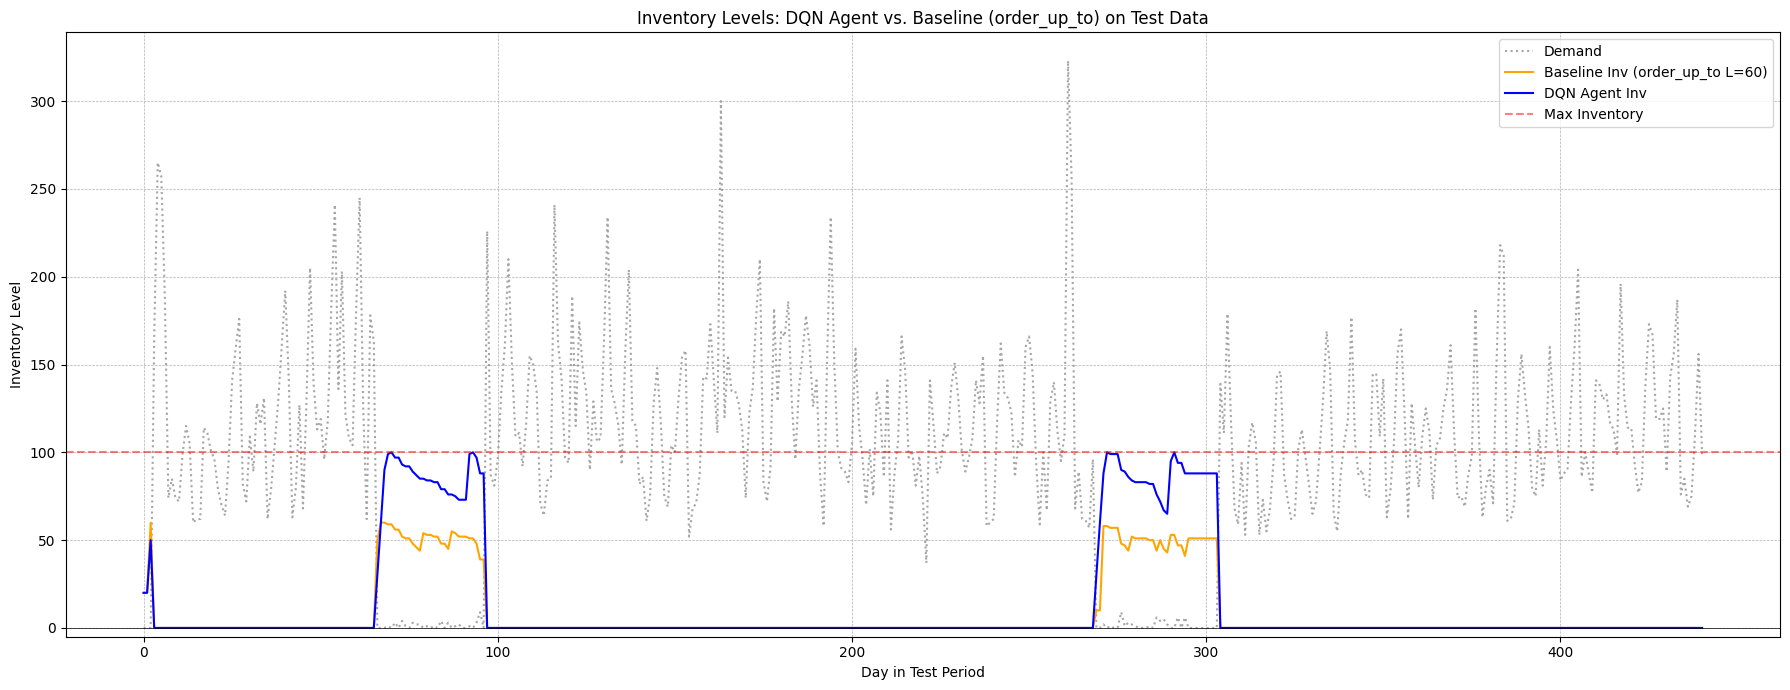

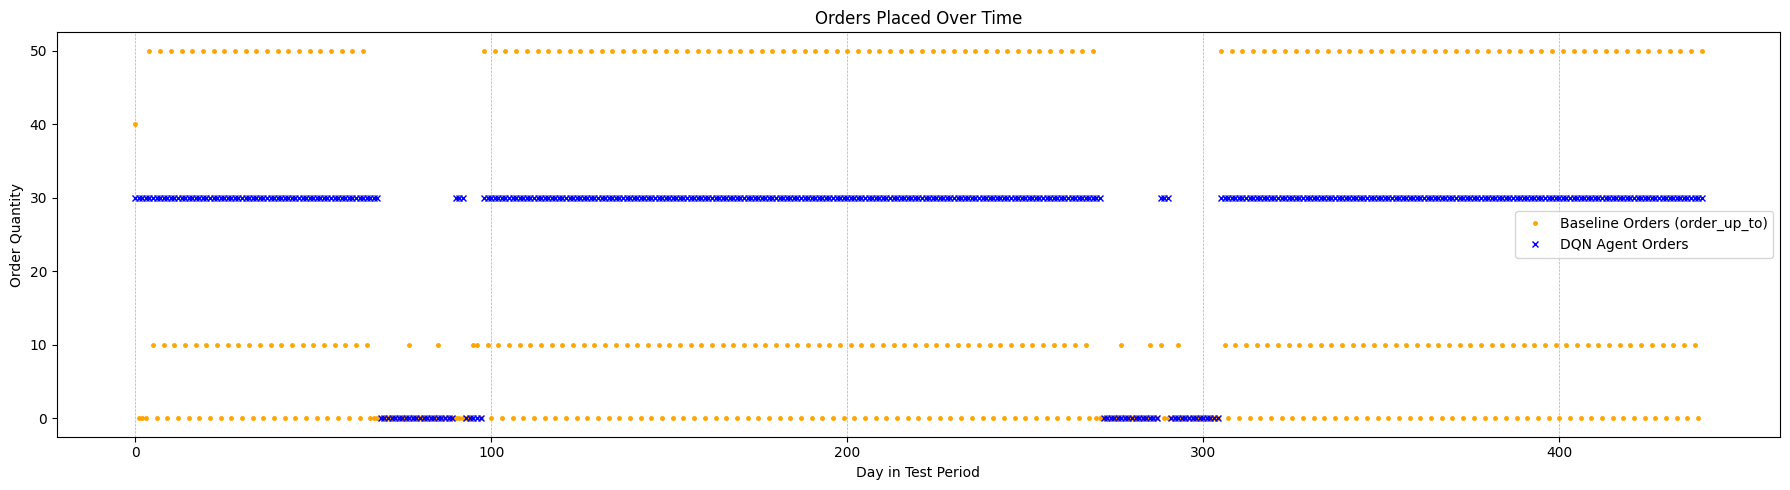


Test environment closed.


In [25]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from stable_baselines3 import DQN

# Assuming InventoryEnv class is defined in inventory_env.py or in the same notebook/cell
# from inventory_env import InventoryEnv
# Assuming run_baseline_policy function is defined (from Step 3)
# from baseline_policy import run_baseline_policy, _find_closest_action_index

# --- Configuration ---

# 1. Define File Paths (Adjust to your Google Drive/Kaggle structure)
PROJECT_DIR = '/kaggle/working/' # Use this if model was saved here
DRIVE_PROJECT_PATH = '/content/drive/MyDrive/Blue_Yonder/' # Or your Colab Drive Path

# Determine base path based on environment
if os.path.exists('/kaggle/input'):
    # Assume loading data from Kaggle input, model from Kaggle working
    INPUT_DATA_PATH = '/kaggle/input/your-m5-data-directory-name/' # CHANGE if needed
    if not os.path.exists(INPUT_DATA_PATH):
       INPUT_DATA_PATH = '/kaggle/input/' # Fallback
    MODEL_BASE_PATH = PROJECT_DIR
    print(f"Running on Kaggle. Data: {INPUT_DATA_PATH}, Model: {MODEL_BASE_PATH}")
else:
    # Assume loading data and model from Drive path
    INPUT_DATA_PATH = DRIVE_PROJECT_PATH
    MODEL_BASE_PATH = DRIVE_PROJECT_PATH # Change if model saved elsewhere
    # Optional: Mount Google Drive if on Colab and not already mounted
    # from google.colab import drive
    # drive.mount('/content/drive')
    print(f"Running locally/Colab. Data/Model: {INPUT_DATA_PATH}")


INPUT_TEST_PATH = os.path.join(PROJECT_DIR, 'demand_test_single_product.npy')
# Use the final model saved at the end of training
MODEL_LOAD_PATH = os.path.join(PROJECT_DIR, 'dqn_inventory_model_final.zip')
# Alternatively, load a specific checkpoint if needed:
# MODEL_LOAD_PATH = os.path.join(MODEL_BASE_PATH, 'dqn_inventory_checkpoint_100000_steps.zip')

# 2. Environment Parameters (MUST match training and baseline parameters)
env_params = {
    # "demand_data": test_demand, # Will be set after loading test data
    "lead_time": 2,
    "holding_cost": 0.2,
    "stockout_cost": 2.0,
    "order_cost": 5.0,
    "max_inventory": 100,
    "max_order_quantity": 50,
    "order_step_size": 10,
    "initial_inventory": 20,
    "include_revenue_in_reward": False # Should match training reward setting
}

# 3. Baseline Policy Parameters (Choose the best/representative one from Step 3)
BASELINE_POLICY_TYPE = 'order_up_to'
BASELINE_POLICY_PARAMS = {'level': 60} # Use the same level tested before

# --- Load Test Data ---
print("\n--- Loading Test Demand Data ---")
try:
    test_demand = np.load(INPUT_TEST_PATH)
    print(f"Loaded test demand data with shape: {test_demand.shape}")
    if len(test_demand) == 0:
        raise ValueError("Test demand data is empty.")
    env_params["demand_data"] = test_demand # Add loaded data to env params
except FileNotFoundError:
    print(f"ERROR: Test demand file not found at {INPUT_TEST_PATH}")
    print("Please ensure 'demand_test_single_product.npy' exists and the path is correct.")
    # Optionally add fallback for testing if needed
    # test_demand = np.random.randint(5, 30, size=413) # Example placeholder
    # env_params["demand_data"] = test_demand
    # print("Using random placeholder demand data for evaluation.")
    raise # Stop execution if file not found
except Exception as e:
    print(f"Error loading test demand data: {e}")
    raise

# --- Instantiate Test Environment ---
print("\n--- Creating Test Environment ---")
test_env = InventoryEnv(**env_params)
# Note: We don't need DummyVecEnv for evaluation with model.predict

# --- Load Trained DQN Model ---
print(f"\n--- Loading Trained DQN Model from {MODEL_LOAD_PATH} ---")
try:
    # The environment passed here is just for initialization context (spaces),
    # it doesn't have to be the same instance we evaluate on.
    model = DQN.load(MODEL_LOAD_PATH, env=test_env)
    print("Model loaded successfully.")
except FileNotFoundError:
    print(f"ERROR: Saved model file not found at {MODEL_LOAD_PATH}")
    print("Ensure the path is correct and the model was saved successfully in Step 4.")
    raise
except Exception as e:
    print(f"Error loading the model: {e}")
    raise

# --- Evaluation Function for RL Agent ---
def evaluate_agent(env: InventoryEnv, model, verbose: bool = False) -> dict:
    """
    Runs the trained RL agent on the environment for one episode using deterministic actions.
    ... (docstring remains the same) ...
    """
    obs, info = env.reset()
    terminated = False
    truncated = False

    # Metrics Tracking
    total_reward = 0.0
    inventory_levels = []
    stockout_events = 0
    order_events = 0
    total_ordered_quantity = 0
    rewards_list = []
    actions_taken = []
    step_count = 0

    while not terminated and not truncated:
        # Use deterministic=True for evaluation (no exploration noise)
        action_array, _states = model.predict(obs, deterministic=True)

        # --- FIX HERE: Convert the scalar action array directly to int ---
        # No indexing needed if it's already 0-dimensional
        action_index = int(action_array)
        # --- End Fix ---

        action_quantity = env._action_to_quantity[action_index] # Use the scalar int key

        if verbose:
             print(f"\nStep {step_count + 1}: Day {info.get('day', 0)}")
             print(f"  State (Inv): {obs[0]:.1f}") # Assuming obs is still flat array for printing
             print(f"  Agent Action: Index={action_index} (Order {action_quantity})")

        # Pass the scalar action index to step
        obs, reward, terminated, truncated, info = env.step(action_index)

        # Record Metrics
        total_reward += reward
        rewards_list.append(reward)
        inventory_levels.append(info['inventory_end_day'])
        actions_taken.append(action_quantity) # Store actual quantity ordered
        if info['unmet_demand'] > 0:
            stockout_events += 1
        if info['order_placed'] > 0:
            order_events += 1
            total_ordered_quantity += info['order_placed']

        if verbose:
            print(f"  -> Reward: {reward:.2f}, Next Inv: {obs[0]:.1f}")
            print(f"     Demand={info['demand']}, Sales={info['sales']}, Unmet={info['unmet_demand']}")

        step_count += 1

        if step_count > env.episode_length * 1.1:
            print("Warning: Exceeded expected episode length. Breaking loop.")
            break

    # --- Calculate Final Metrics (remains the same) ---
    avg_inventory = np.mean(inventory_levels) if inventory_levels else 0
    stockout_percentage = (stockout_events / step_count * 100) if step_count > 0 else 0
    # ... other metrics ...

    results = {
        # ... (populate results dict - remains the same) ...
         "policy_type": "DQN Agent",
         "total_reward": total_reward,
         "average_inventory": avg_inventory,
         "total_steps": step_count,
         "stockout_days": stockout_events,
         "stockout_percentage": stockout_percentage,
         "order_days": order_events,
         "order_frequency_percentage": (order_events / step_count * 100) if step_count > 0 else 0,
         "average_order_quantity": (total_ordered_quantity / order_events) if order_events > 0 else 0,
         "final_inventory": obs[0] if step_count > 0 else env.initial_inventory,
         "inventory_trajectory": inventory_levels,
         "reward_trajectory": rewards_list,
         "action_trajectory": actions_taken
    }

    print(f"\n--- RL Agent Evaluation Results ---")
    for key, value in results.items():
        if key.endswith("trajectory"): continue
        if isinstance(value, float): print(f"  {key}: {value:.2f}")
        else: print(f"  {key}: {value}")

    return results

# --- Run Evaluation ---
print("\n--- Evaluating Trained DQN Agent ---")
rl_results = evaluate_agent(test_env, model, verbose=False) # Set verbose=True for details

# --- Re-run Baseline for Direct Comparison (using same test_env instance) ---
print(f"\n--- Re-running Baseline Policy ({BASELINE_POLICY_TYPE}) for Comparison ---")

# Need to potentially redefine the baseline runner function if it's not imported
# Make sure _find_closest_action_index is available if needed by run_baseline_policy
# (Assuming run_baseline_policy and helpers are defined above or imported)

# Modify run_baseline_policy slightly to return inventory trajectory for plotting
def run_baseline_policy_with_trajectory(env: InventoryEnv, policy_type: str = 'order_up_to', policy_params: dict = None, verbose: bool = False) -> dict:
    # ... (Keep the main logic from Step 3's run_baseline_policy) ...
    obs, info = env.reset()
    terminated, truncated = False, False
    total_reward = 0.0
    inventory_levels = [] # Store trajectory
    stockout_events, order_events, total_ordered_quantity = 0, 0, 0
    step_count = 0
    rewards_list = []
    actions_taken = []

    while not terminated and not truncated:
        current_inventory = obs[0]
        on_order_inventory = info.get('on_order_total', 0)
        target_order_quantity = 0
        # --- Policy Logic (same as Step 3) ---
        if policy_type == 'order_up_to':
            level = policy_params.get('level', 50)
            target_order_quantity = max(0, level - current_inventory - on_order_inventory)
        elif policy_type == 'fixed_order':
            order_interval = policy_params.get('order_interval', 7)
            fixed_quantity = policy_params.get('fixed_quantity', env.max_order_quantity // 2)
            if step_count % order_interval == 0:
                 # Add validation for fixed_quantity vs possible_orders here if needed
                 target_order_quantity = fixed_quantity
        else:
            raise ValueError(f"Unknown policy_type: {policy_type}")

        action = _find_closest_action_index(env, int(round(target_order_quantity)))
        actual_order_quantity = env._action_to_quantity[action]

        # --- Step ---
        obs, reward, terminated, truncated, info = env.step(action)

        # --- Record ---
        total_reward += reward
        rewards_list.append(reward)
        inventory_levels.append(info['inventory_end_day'])
        actions_taken.append(actual_order_quantity)
        if info['unmet_demand'] > 0: stockout_events += 1
        if info['order_placed'] > 0:
            order_events += 1
            total_ordered_quantity += info['order_placed']
        step_count += 1
        # ... (rest of loop, safety break) ...

    # --- Calculate Final Metrics (same as Step 3) ---
    avg_inventory = np.mean(inventory_levels) if inventory_levels else 0
    stockout_percentage = (stockout_events / step_count * 100) if step_count > 0 else 0
    order_frequency = (order_events / step_count * 100) if step_count > 0 else 0
    avg_order_quantity = (total_ordered_quantity / order_events) if order_events > 0 else 0

    results = {
        "policy_type": f"Baseline ({policy_type})", # Clarify it's baseline
        "policy_params": policy_params,
        "total_reward": total_reward,
        "average_inventory": avg_inventory,
        "total_steps": step_count,
        "stockout_days": stockout_events,
        "stockout_percentage": stockout_percentage,
        "order_days": order_events,
        "order_frequency_percentage": order_frequency,
        "average_order_quantity": avg_order_quantity,
        "final_inventory": obs[0] if step_count > 0 else env.initial_inventory,
        "inventory_trajectory": inventory_levels, # <<< Added for plotting
        "reward_trajectory": rewards_list,
        "action_trajectory": actions_taken
    }
    # Print results within the function or outside
    print(f"\n--- Baseline Policy Results ({policy_type}) ---")
    for key, value in results.items():
        if key.endswith("trajectory"): continue
        if isinstance(value, float): print(f"  {key}: {value:.2f}")
        else: print(f"  {key}: {value}")
    return results
# End of modified baseline function definition

# Now run the modified baseline function
baseline_results = run_baseline_policy_with_trajectory(
    test_env, # Use the same env instance
    policy_type=BASELINE_POLICY_TYPE,
    policy_params=BASELINE_POLICY_PARAMS,
    verbose=False
)

# --- Comparison ---
print("\n--- Performance Comparison (RL Agent vs Baseline) ---")

# Create a DataFrame for nice formatting
metrics_to_compare = [
    'total_reward', 'average_inventory', 'stockout_percentage',
    'order_frequency_percentage', 'average_order_quantity'
]

# Extract relevant metrics, handling potential missing keys if needed
comparison_data = {
    'Metric': metrics_to_compare,
    'DQN Agent': [rl_results.get(m, 'N/A') for m in metrics_to_compare],
    f'Baseline ({BASELINE_POLICY_TYPE} L={BASELINE_POLICY_PARAMS.get("level", "N/A")})': [baseline_results.get(m, 'N/A') for m in metrics_to_compare]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Add interpretation based on reward (assuming higher reward is better if profit, or closer to 0 if cost minimization)
print("\nInterpretation:")
if env_params["include_revenue_in_reward"]:
    if rl_results['total_reward'] > baseline_results['total_reward']:
        print(" -> RL Agent achieved higher total profit than the baseline.")
    elif rl_results['total_reward'] < baseline_results['total_reward']:
        print(" -> Baseline achieved higher total profit than the RL Agent.")
    else:
        print(" -> RL Agent and Baseline achieved similar total profit.")
else: # Cost minimization (reward = -cost)
    if rl_results['total_reward'] > baseline_results['total_reward']:
        print(f" -> RL Agent achieved lower total cost (Reward: {rl_results['total_reward']:.2f}) than the Baseline (Reward: {baseline_results['total_reward']:.2f}).")
    elif rl_results['total_reward'] < baseline_results['total_reward']:
        print(f" -> Baseline achieved lower total cost (Reward: {baseline_results['total_reward']:.2f}) than the RL Agent (Reward: {rl_results['total_reward']:.2f}).")
    else:
        print(f" -> RL Agent and Baseline achieved similar total cost (Reward: {rl_results['total_reward']:.2f}).")


# --- (Optional) Plotting ---
print("\n--- Plotting Inventory Levels ---")
plt.figure(figsize=(18, 7))

# Time axis (number of steps/days in the test set)
time_axis = np.arange(len(test_demand))

# Plot Demand (Optional, for context)
plt.plot(time_axis, test_demand, label='Demand', color='gray', linestyle=':', alpha=0.7, linewidth=1.5)

# Plot Baseline Inventory
plt.plot(time_axis, baseline_results['inventory_trajectory'], label=f'Baseline Inv ({BASELINE_POLICY_TYPE} L={BASELINE_POLICY_PARAMS.get("level", "N/A")})', color='orange', linewidth=1.5)

# Plot RL Agent Inventory
plt.plot(time_axis, rl_results['inventory_trajectory'], label=f'DQN Agent Inv', color='blue', linewidth=1.5)

# Plot Inventory Capacity (Optional)
plt.axhline(y=env_params['max_inventory'], color='red', linestyle='--', label='Max Inventory', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5) # Zero line

plt.title(f'Inventory Levels: DQN Agent vs. Baseline ({BASELINE_POLICY_TYPE}) on Test Data')
plt.xlabel('Day in Test Period')
plt.ylabel('Inventory Level')
plt.ylim(bottom=-5) # Start y-axis slightly below 0
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# Optional: Plot Actions/Orders
plt.figure(figsize=(18, 5))
plt.plot(time_axis, baseline_results['action_trajectory'], label=f'Baseline Orders ({BASELINE_POLICY_TYPE})', color='orange', marker='.', linestyle='None', markersize=5)
plt.plot(time_axis, rl_results['action_trajectory'], label=f'DQN Agent Orders', color='blue', marker='x', linestyle='None', markersize=5)
plt.title('Orders Placed Over Time')
plt.xlabel('Day in Test Period')
plt.ylabel('Order Quantity')
plt.legend()
plt.grid(True, axis='x', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


# Clean up the environment
test_env.close()
print("\nTest environment closed.")

In [27]:
import os
from transformers import pipeline, set_seed
import warnings
import torch # Or tensorflow if using TF backend

# Suppress specific warnings from the pipeline if needed
warnings.filterwarnings("ignore", message="Setting `pad_token_id` to `eos_token_id`")

# --- Configuration ---
# Use a smaller model suitable for free tiers
# Other options: 'gpt2', 'google/flan-t5-small' (use 'text2text-generation' pipeline for T5)
MODEL_NAME = 'distilgpt2'
PIPELINE_TASK = 'text-generation' # Use 'text2text-generation' for T5 models

# --- Load Model and Tokenizer using Pipeline ---

def load_llm_pipeline(model_name: str = MODEL_NAME, task: str = PIPELINE_TASK):
    """Loads the LLM model and tokenizer using the Hugging Face pipeline."""
    print(f"Loading LLM pipeline for model: '{model_name}' (task: '{task}')...")
    try:
        # Check device availability (use GPU if possible on Colab/Kaggle)
        device = 0 if torch.cuda.is_available() else -1 # device=0 for GPU, -1 for CPU
        print(f"Using device: {'GPU' if device == 0 else 'CPU'}")

        generator_pipeline = pipeline(
            task,
            model=model_name,
            device=device # Specify the device
            )
        print("LLM pipeline loaded successfully.")
        return generator_pipeline
    except Exception as e:
        print(f"Error loading LLM pipeline: {e}")
        print("Please ensure you have an internet connection and the necessary libraries installed.")
        print("Try installing with: pip install transformers torch (or tensorflow)")
        return None

# --- LLM Interaction Functions ---

def generate_scenario(generator_pipeline,
                      prompt: str,
                      max_new_tokens: int = 100,
                      num_return_sequences: int = 1,
                      seed: int = 42) -> str:
    """
    Generates text based on a prompt using the loaded text-generation pipeline.

    Args:
        generator_pipeline: The loaded Hugging Face pipeline.
        prompt: The input text prompt for the LLM.
        max_new_tokens: The maximum number of new tokens to generate after the prompt.
        num_return_sequences: The number of different sequences to generate.
        seed: Random seed for reproducibility.

    Returns:
        The generated text (only the new part, excluding the prompt).
        Returns an error message string if generation fails.
    """
    if generator_pipeline is None:
        return "Error: LLM pipeline not loaded."

    set_seed(seed) # Set seed for reproducibility

    try:
        # Generate text
        # Note: max_length usually includes prompt length. max_new_tokens is often clearer.
        outputs = generator_pipeline(
            prompt,
            max_new_tokens=max_new_tokens,
            num_return_sequences=num_return_sequences,
            pad_token_id=generator_pipeline.tokenizer.eos_token_id, # Suppress warning
            no_repeat_ngram_size=2, # Reduce repetition
            do_sample=True, # Use sampling for more diverse output
            temperature=0.7, # Control randomness (lower = more focused)
            top_k=50 # Consider top k tokens for sampling
        )

        # Extract the generated text (excluding the prompt)
        generated_text_full = outputs[0]['generated_text']
        # Remove the original prompt from the beginning
        if generated_text_full.startswith(prompt):
            generated_text_new = generated_text_full[len(prompt):].strip()
        else:
            # Fallback if prompt isn't exactly at the start (less likely with pipeline)
            generated_text_new = generated_text_full.strip()

        return generated_text_new

    except Exception as e:
        print(f"Error during text generation: {e}")
        return f"Error generating text: {e}"


def explain_text(generator_pipeline,
                 prompt: str,
                 max_new_tokens: int = 80,
                 seed: int = 42) -> str:
    """
    Uses the LLM to generate an explanation based on the provided prompt
    (which should include the context or data to be explained).

    Args:
        generator_pipeline: The loaded Hugging Face pipeline.
        prompt: The input text prompt, including the data/context and the request.
        max_new_tokens: Max tokens for the explanation.
        seed: Random seed.

    Returns:
        The generated explanation (only the new part, excluding the prompt).
        Returns an error message string if generation fails.
    """
    # This function reuses generate_scenario as the underlying mechanism is the same.
    # The key difference is the structure of the prompt provided by the user.
    return generate_scenario(generator_pipeline, prompt, max_new_tokens=max_new_tokens, seed=seed)


# --- Example Usage & Testing ---

if __name__ == "__main__":
    print("\n--- Setting up LLM Interaction ---")
    llm_generator = load_llm_pipeline()

    if llm_generator:
        print("\n--- Testing Scenario Generation ---")
        scenario_prompt = "Describe a plausible scenario causing a two-week demand spike for toilet paper in a specific region:"
        print(f"Prompt:\n{scenario_prompt}\n")
        generated_scenario = generate_scenario(llm_generator, scenario_prompt, max_new_tokens=120)
        print(f"Generated Scenario:\n{generated_scenario}\n")

        print("--- Testing Text Explanation ---")
        # Example data snippet (replace with actual data if desired)
        inventory_data_snippet = """
        Recent Inventory Data:
        Week 1: Avg Inv=85, Stockouts=0 days
        Week 2: Avg Inv=70, Stockouts=0 days
        Week 3: Avg Inv=35, Stockouts=2 days
        Week 4: Avg Inv=45, Stockouts=1 day (Order arrived mid-week)
        """
        explanation_prompt = f"Explain the following inventory data trends in simple terms for a non-expert:\n{inventory_data_snippet}\nExplanation:"
        print(f"Prompt:\n{explanation_prompt}\n")
        generated_explanation = explain_text(llm_generator, explanation_prompt, max_new_tokens=100)
        print(f"Generated Explanation:\n{generated_explanation}\n")

        print("--- Testing Edge Case (Short Prompt) ---")
        short_prompt = "Inventory management is"
        print(f"Prompt: {short_prompt}")
        short_output = generate_scenario(llm_generator, short_prompt, max_new_tokens=30)
        print(f"Generated Output: {short_output}\n")

    else:
        print("LLM pipeline could not be loaded. Skipping tests.")


--- Setting up LLM Interaction ---
Loading LLM pipeline for model: 'distilgpt2' (task: 'text-generation')...
Using device: GPU


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0


LLM pipeline loaded successfully.

--- Testing Scenario Generation ---
Prompt:
Describe a plausible scenario causing a two-week demand spike for toilet paper in a specific region:

Generated Scenario:
I have a couple of other ideas to look into in this article. For example, let's say a person walks into the city and uses toiletpaper in the same city. In the case of a hotel, we must call the hotel where we work and demand that the toilet be used. To find out, I've had a lot of conversations with a number of people. One of them was this one. I was in an office where I had to get a toilet, and I asked about the situation. A person called me, saying: "Is this a problem? Is this not

--- Testing Text Explanation ---
Prompt:
Explain the following inventory data trends in simple terms for a non-expert:

        Recent Inventory Data:
        Week 1: Avg Inv=85, Stockouts=0 days
        Week 2: Avg Inv=70, Stockouts=0 days
        Week 3: Avg Inv=35, Stockouts=2 days
        Week 4: Avg Inv=45